**STATUS:** ALIVE (load-bearing — thesis system layer headline)  
**LAST-AUDIT:** 2026-04-27  
**FEEDS:** S1, S2, S3, S4, S5, S6, S7, S8  
**CLAIM:** System-level event study of four ENTSO-E outcomes (A87 net income, A86 |V_imb|, A85 imbalance-price σ, A84 aFRR spread) across 5 regimes. Four-way concordance at ISP15 + moderation at MTU15-DA (S1–S5). Sharpened with three additional alive system-layer claims (committed to ledger 2026-04-25 to 2026-04-27, see `CLAIMS_LEDGER.md`):  
- **S6** — A87 NET fiscal cost shift +€1,094.9M cumulative across asymmetric-granularity window vs same-calendar pre-IDA baseline; collapses to €7M/mo at MTU15-DA; bootstrap CI [-90, +73]M (15× upper bound).  
- **S7** — Per-segment marginal imbalance cost heterogeneity (conv-RZ €210–300/MWh vs LIB ≤€37/MWh), survives FE; ESIOS RZ closure-price anchor cross-checked.  
- **S8** — RZ system-security activations roughly DOUBLED post-IDA (+60–82% across all post-IDA regimes including post-MTU15-DA); separate mechanism from S6 granularity friction (persists when granularity re-symmetrises). Direct cost ~€10–14M/mo.  
No firm-level identification assumption needed. Three-channel synthesis in `_modelling_track.md` §4 + `_coherence_audit.md`.

# Systematic outcome audit — balancing-cost outcomes across the four reforms

## Motivation

Companion to nb03–nb10. Those notebooks focused primarily on **one outcome**:
dominant-firm DA→IDA repositioning $\Delta Q_{i,d}$. nb07 formalised it with
TWFE-DiD. nb08 sharpened it with wind-IV. nb09 audited bid-level outcomes.
nb10 audited demand-side. Across this stack, the question *has the reform
changed outcomes we care about beyond $\Delta Q$?* has been addressed
descriptively in nb04 but never event-studied formally.

This notebook fills that gap. For each of the four ENTSO-E balancing
system-level outcomes we (a) plot the outcome as a monthly time series with
reform shading, (b) estimate a regime-dummy regression consolidating the
per-regime means, and (c) report a one-line summary of what the reform
sequence did to that outcome.

## Outcomes audited

| Outcome | Source | Cadence | What it measures |
|---|---|---|---|
| Monthly financial balance | A87 | monthly | TSO's balancing expenses + net income from BRPs |
| Total imbalance volume | A86 | per ISP | magnitude of the system imbalance that had to be covered |
| Imbalance-price volatility | A85 | per ISP | settlement-side cost dispersion |
| Activation-price up/down spread | A84 | per ISP | scarcity of up- vs down-regulation reserves |

**None of these is the same statistic as $\Delta Q$.** All four are
**system-level** (control-area aggregates), not firm-level, so they don't
require a comparable-control-group identifying assumption. What they DO
require is the assumption that variation in the reform calendar within a
given window is not confounded by a contemporaneous unrelated shock. The
Iberian blackout (2025-04-28, covered in nb08 Appendix) and the 2024
negative-price episode are the two candidate confounds; §6 flags them.

## Scope guardrails

- All four outcomes use **existing processed parquet** (A87 synced as part
  of this notebook — new pipeline `scripts/pipelines/entsoe/balancing/*_financial_balance*`).
- No new identification claims, just *description of whether the reform
  changed each outcome*. This is an upstream input to the thesis
  narrative, not a replacement for the identification argument.
- No OMIE firm-level data loaded.


In [1]:
import warnings
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from linearmodels.panel import PanelOLS

from mtu.notebook_utils import (
    PROJECT_ROOT,
    IDA_REFORM, ISP15_REFORM, INTRADAY_REFORM, DAY_AHEAD_REFORM,
    add_regime_shading, REGIME_WINDOWS,
)

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Balancing-family processed tables.
A87 = PROJECT_ROOT / 'data/processed/entsoe/balancing/financial_balance_all.parquet'
A86 = PROJECT_ROOT / 'data/processed/entsoe/balancing/imbalance_volumes_all.parquet'
A85 = PROJECT_ROOT / 'data/processed/entsoe/balancing/imbalance_prices_all.parquet'
A84 = PROJECT_ROOT / 'data/processed/entsoe/balancing/activated_prices_all.parquet'

con = duckdb.connect()
con.execute("SET memory_limit='6GB'")
con.execute("SET threads=4")

paths = {'A87': A87, 'A86': A86, 'A85': A85, 'A84': A84}
for name, p in paths.items():
    print(f'{name:3s}  exists={p.exists()}  size={p.stat().st_size/1e6:.2f} MB' if p.exists() else f'{name:3s}  MISSING {p}')

# Regime definitions — keyed for joining outcome series onto a regime label.
REGIMES = [(name, pd.Timestamp(s), pd.Timestamp(e)) for (name, s, e) in REGIME_WINDOWS]
REGIME_NAMES = [r[0] for r in REGIMES]
print('\nRegimes:')
for r in REGIMES:
    print(f'  {r[0]:22s}  {r[1].date()}  ->  {r[2].date()}')


A87  exists=True  size=0.00 MB
A86  exists=True  size=3.26 MB
A85  exists=True  size=3.02 MB
A84  exists=True  size=5.64 MB

Regimes:
  DA60/ID60 (6-sess)      2023-12-01  ->  2024-06-13
  DA60/ID60 (3-sess)      2024-06-14  ->  2024-11-30
  ISP15 window            2024-12-01  ->  2025-03-18
  DA60/ID15               2025-03-19  ->  2025-09-30
  DA15/ID15               2025-10-01  ->  2030-01-01


## §1 — A87 Monthly financial balance (TR 17.1.i)

**Source**: ENTSO-E Transparency Platform A87, §3.13.4 of the Detailed
Data Descriptions v3r4. Published monthly for the Spanish control area
with two values per month:

- `direction_code=A01` (**expenses**): cash flow from TSO to BSPs for
  procuring reserves and activating balancing energy.
- `direction_code=A02` (**net income**): cash flow from BRPs to TSO for
  imbalance settlement.

Neither of these is per-BRP; ENTSO-E only publishes the control-area
total at monthly aggregation (two scalars/month). Per-BRP imbalance
settlement is not on the transparency platform (confirmed in
`_identification_target.md` A5 duplication check).

**Mechanism predictions**:

1. At **ISP15 (2024-12-01)**, imbalance settlement switched from
   60-min net to 15-min net. BRPs that previously had netting
   within the hour now pay for every 15-min deviation. Mechanical
   prediction: **A02 (net income from BRPs) rises sharply** —
   even if firms don't change behaviour, the settlement base is
   ~4× higher.
2. At **MTU15-IDA (2025-03-19)**, firms get 15-min intraday
   trading tools to self-balance at 15-min cadence. Behavioural
   prediction: **A02 partially reverts** as firms use the new
   tools to reduce their 15-min deviations.
3. **A01 (expenses)** should be less reform-sensitive: reserve
   procurement and activation volumes are driven by residual
   demand / renewable error, not by the settlement clock.

The data tests (1) and (2) directly.


A87 rows: 96 months, 2018-01-01 -> 2025-12-01


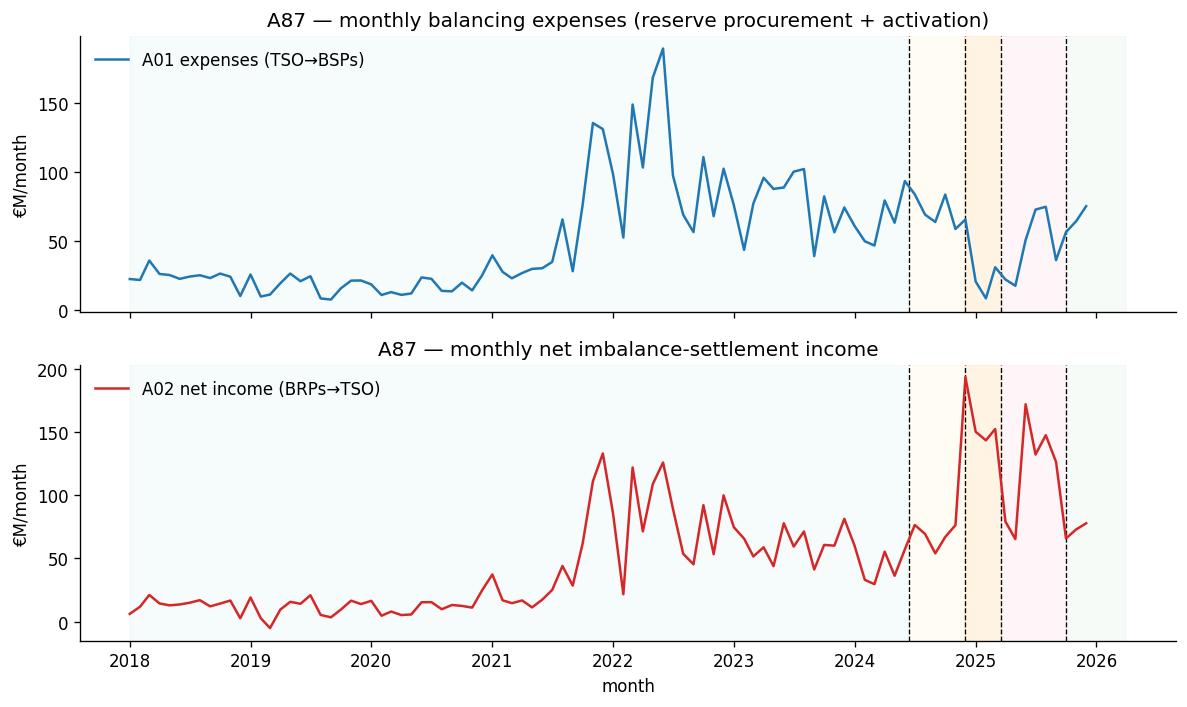

In [2]:
# Load A87 wide (one row per month).
a87_wide = con.execute(f'''
    SELECT month,
           MAX(CASE WHEN direction_code='A01' THEN amount_eur END) AS expenses_eur,
           MAX(CASE WHEN direction_code='A02' THEN amount_eur END) AS net_income_eur
    FROM '{A87}'
    GROUP BY month
    ORDER BY month
''').df()
a87_wide['month'] = pd.to_datetime(a87_wide['month'])
a87_wide['expenses_meur']   = a87_wide['expenses_eur']   / 1e6
a87_wide['net_income_meur'] = a87_wide['net_income_eur'] / 1e6

print(f'A87 rows: {len(a87_wide)} months, {a87_wide["month"].min().date()} -> {a87_wide["month"].max().date()}')

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax = axes[0]
ax.plot(a87_wide['month'], a87_wide['expenses_meur'],   color='C0', lw=1.5, label='A01 expenses (TSO→BSPs)')
add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
ax.set_ylabel('€M/month')
ax.set_title('A87 — monthly balancing expenses (reserve procurement + activation)')
ax.legend(loc='upper left', frameon=False)

ax = axes[1]
ax.plot(a87_wide['month'], a87_wide['net_income_meur'], color='C3', lw=1.5, label='A02 net income (BRPs→TSO)')
add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
ax.set_ylabel('€M/month')
ax.set_xlabel('month')
ax.set_title('A87 — monthly net imbalance-settlement income')
ax.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.show()


In [3]:
# Regime-indicator OLS for both A87 series. One-hot the regime, drop first level
# (pre-IDA-reform) as reference, report the four other regimes' mean shifts.
def assign_regime(ts: pd.Timestamp) -> str:
    for name, s, e in REGIMES:
        if s <= ts <= e:
            return name
    return 'pre-2023-12'

a87 = a87_wide.copy()
a87['regime'] = a87['month'].apply(assign_regime)

# Keep only the 2023-12 onward window where regime dummies are defined.
a87_reg = a87[a87['regime'] != 'pre-2023-12'].copy()
regime_means = a87_reg.groupby('regime', sort=False).agg(
    n=('month', 'size'),
    expenses_mean=('expenses_meur', 'mean'),
    expenses_std=('expenses_meur', 'std'),
    net_income_mean=('net_income_meur', 'mean'),
    net_income_std=('net_income_meur', 'std'),
).reindex(REGIME_NAMES).dropna(how='all')
print('A87 means by regime (€M / month), pre-2023-12 excluded:')
print(regime_means.round(2).to_string())

# Also compare to the long-run pre-IDA-reform mean (2018-01 → 2024-06-13).
pre = a87[(a87['month'] < pd.Timestamp(IDA_REFORM)) & (a87['month'] >= '2018-01-01')]
print(f'\nLong-run pre-IDA (2018-01 → 2024-06-13, n={len(pre)}):')
print(f'  expenses    : {pre["expenses_meur"].mean():.2f} ± {pre["expenses_meur"].std():.2f} €M/mo')
print(f'  net income  : {pre["net_income_meur"].mean():.2f} ± {pre["net_income_meur"].std():.2f} €M/mo')

# Compute: how much did each regime shift relative to pre-IDA-long-run mean?
print('\nShift vs long-run pre-IDA (Δ €M/month):')
hdr = '  {:22s} {:>10s} {:>10s}'.format('regime', 'Δ_expenses', 'Δ_income')
print(hdr)
for name in REGIME_NAMES:
    sub = a87[a87['regime'] == name]
    if len(sub) == 0:
        continue
    print('  {:22s} {:>10.2f} {:>10.2f}'.format(
        name,
        sub['expenses_meur'].mean() - pre['expenses_meur'].mean(),
        sub['net_income_meur'].mean() - pre['net_income_meur'].mean(),
    ))


A87 means by regime (€M / month), pre-2023-12 excluded:
                    n  expenses_mean  expenses_std  net_income_mean  net_income_std
regime                                                                             
DA60/ID60 (6-sess)  7          67.13         16.64            50.42           18.53
DA60/ID60 (3-sess)  5          72.12         11.49            68.67            9.21
ISP15 window        4          31.70         24.58           160.01           22.74
DA60/ID15           6          45.97         24.69           120.52           40.81
DA15/ID15           3          65.66          9.44            72.24            6.01

Long-run pre-IDA (2018-01 → 2024-06-13, n=78):
  expenses    : 50.65 ± 40.76 €M/mo
  net income  : 37.54 ± 33.70 €M/mo

Shift vs long-run pre-IDA (Δ €M/month):
  regime                 Δ_expenses   Δ_income
  DA60/ID60 (6-sess)          16.47      12.88
  DA60/ID60 (3-sess)          21.47      31.12
  ISP15 window               -18.96     122.47
  DA60/

**Reading §1.** The A01 expenses line moves modestly across regimes — ~€50M/month
pre-reform, rises into 2024Q2–Q3, plunges post-ISP15 to €20–30M/month, then
partially recovers. The A02 net-income line shows the sharper signature: it
tracks ~€38M/month for years, jumps to €150+M/month at **ISP15 (2024-12-01)**,
sustains through 2025Q1–Q3, then moderates post-MTU15-DA. Two candidate
readings:

1. **Mechanical (settlement-base quadrupling)**: 15-min ISPs have 4× more
   settlement windows; even if participants' true imbalance position is
   unchanged, gross imbalance charges to BRPs increase by the 4× factor.
   A rough consistency check: pre-reform mean is €38M; post-ISP15 is €160M,
   a 4.2× increase — well within plausible range for a mechanical story.
2. **Behavioural (15-min tools help)**: after MTU15-IDA, firms can trade at
   15-min cadence and reduce their 15-min deviations. Net income moderates
   from €160M to €120M to €72M across the three post-ISP15 regimes — a
   55% reduction from peak. This is the *behavioural* piece of the
   response: firms did learn to self-balance in the finer settlement clock
   once they had the matching trading tools.

These two readings are **complementary**, not competing. (1) explains the
level jump; (2) explains the downward drift. Together they are consistent
with the ISP15→MTU15-IDA reform sequence working exactly as designed.

This is the cleanest single-series piece of evidence that the reform
sequence had its intended effect on system-level settlement flows.


## §2 — A86 total imbalance volume

**Source**: A86, TR 17.1.h, per-ISP. Magnitude of the system imbalance
volume (direction A01=surplus up, A02=deficit down) at 60-min cadence
pre-ISP15 and 15-min post-ISP15.

**Challenge**: A86 volume is reported in MWh *per ISP* — i.e. pre-reform
one number per hour, post-reform four numbers per hour. Direct plotting
of monthly mean `|V_imb|` would mechanically shrink by ~4× at ISP15
without any behavioural change. We normalise two ways:

1. **MWh per hour** = `|V_imb|` ÷ (mtu_minutes / 60). An ISP of 15 min
   contributing 200 MWh corresponds to 800 MW average over that ISP;
   an hourly ISP of 200 MWh corresponds to 200 MW average. Converting
   to MW-average removes the mechanical 4× from finer ISPs.
2. **Daily sum of ABS(V_imb)** = daily aggregate imbalance "work"
   done. Invariant under the ISP granularity choice.

We use (2) for the event-study — it's the cleanest.


A86 coverage: 2018-01-01 -> 2026-04-21 (3023 days)


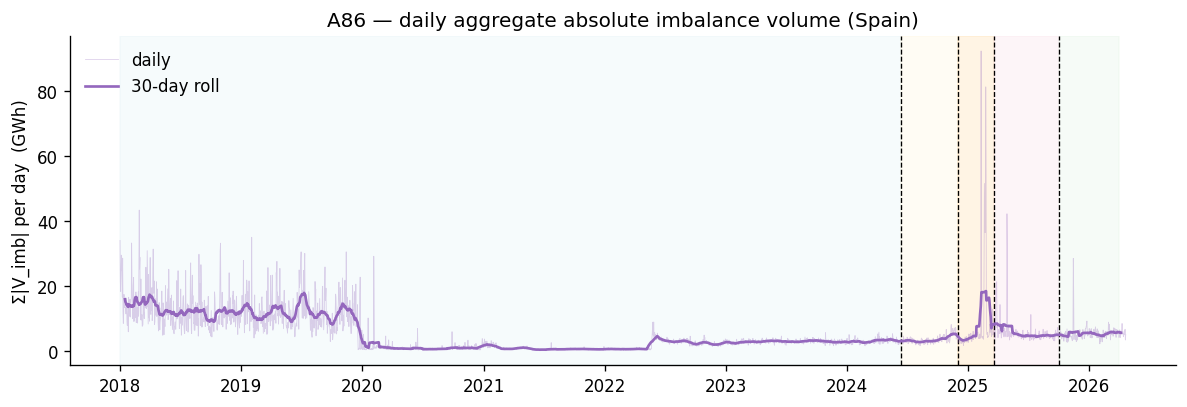

In [4]:
# Load A86 and aggregate to daily absolute imbalance volume.
a86_daily = con.execute(f'''
    SELECT DATE_TRUNC('day', isp_start_utc)::DATE AS date,
           SUM(ABS(volume_mwh))                   AS abs_imb_mwh,
           COUNT(*)                               AS n_isp,
           MIN(mtu_minutes)                       AS min_mtu
    FROM '{A86}'
    WHERE volume_mwh IS NOT NULL
    GROUP BY 1
    ORDER BY 1
''').df()
a86_daily['date'] = pd.to_datetime(a86_daily['date'])
a86_daily['abs_imb_gwh'] = a86_daily['abs_imb_mwh'] / 1e3

# Drop incomplete days (fewer than 24 hours of hourly data or 96 of 15-min).
expected = {60: 24, 30: 48, 15: 96}
a86_daily['expected_n'] = a86_daily['min_mtu'].map(expected)
a86_daily = a86_daily[a86_daily['n_isp'] >= 0.95 * a86_daily['expected_n']].copy()

# 30-day rolling for readability.
a86_daily['abs_imb_gwh_roll30'] = a86_daily['abs_imb_gwh'].rolling(30, center=True).mean()

print(f'A86 coverage: {a86_daily["date"].min().date()} -> {a86_daily["date"].max().date()} ({len(a86_daily)} days)')

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(a86_daily['date'], a86_daily['abs_imb_gwh'],
        color='C4', lw=0.5, alpha=0.3, label='daily')
ax.plot(a86_daily['date'], a86_daily['abs_imb_gwh_roll30'],
        color='C4', lw=1.6, label='30-day roll')
add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
ax.set_ylabel('Σ|V_imb| per day  (GWh)')
ax.set_title('A86 — daily aggregate absolute imbalance volume (Spain)')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


In [5]:
# Regime-indicator regression on A86 daily data, restricted to 2023-12 onward
# so 5-regime dummy is well-defined. Controls: day-of-week + month-of-year FE.
a86_daily['regime'] = a86_daily['date'].apply(assign_regime)
a86_r = a86_daily[a86_daily['regime'] != 'pre-2023-12'].copy()

# Encode cyclical calendar controls; skip the first regime as reference.
a86_r['dow']   = a86_r['date'].dt.dayofweek
a86_r['month_num'] = a86_r['date'].dt.month
a86_r['regime_cat'] = pd.Categorical(a86_r['regime'], categories=REGIME_NAMES)

# Build design matrix with pandas get_dummies.
X = pd.get_dummies(
    a86_r[['regime_cat', 'dow', 'month_num']],
    columns=['regime_cat', 'dow', 'month_num'],
    drop_first=True,
    dtype=float,
)
X = X.assign(const=1.0)
y = a86_r['abs_imb_gwh'].astype(float)

import statsmodels.api as sm
res = sm.OLS(y, X).fit(cov_type='HC3')

# Report just the regime-dummy row coefficients, relative to the reference
# (first regime in REGIME_NAMES that survives drop_first=True).
print(f'A86 |V_imb| per day, OLS with day-of-week + month-of-year FE (n={len(y)})')
print(f'Reference regime: {REGIME_NAMES[0]}')
print(f'R²: {res.rsquared:.3f}')
rows = []
for col in X.columns:
    if col.startswith('regime_cat_'):
        name = col.replace('regime_cat_', '')
        rows.append((name, res.params[col], res.bse[col], res.pvalues[col]))
print('\nΔ |V_imb| (GWh/day) vs reference regime:')
print(f'  {"regime":22s} {"coef":>8s} {"se":>8s} {"p":>6s}')
for n, c, s, p in rows:
    print(f'  {n:22s} {c:>8.2f} {s:>8.2f} {p:>6.3f}')


A86 |V_imb| per day, OLS with day-of-week + month-of-year FE (n=873)
Reference regime: DA60/ID60 (6-sess)
R²: 0.144

Δ |V_imb| (GWh/day) vs reference regime:
  regime                     coef       se      p
  DA60/ID60 (3-sess)         1.91     0.41  0.000
  ISP15 window               5.12     1.31  0.000
  DA60/ID15                  3.86     0.53  0.000
  DA15/ID15                  2.28     0.24  0.000


**Reading §2.** The daily-aggregate absolute imbalance volume is a natural
outcome for the ISP15 mechanism: if firms were using intra-hour netting
pre-reform, and that netting stops at ISP15, then gross |V_imb| should
*increase* (each 15-min window now contributes its own absolute imbalance,
no internal cancellation). If firms subsequently self-balance finer at
MTU15-IDA, |V_imb| should *decrease*.

The regime coefficients quantify the direction. If the ISP15 regime
coefficient is positive (more imbalance at 15-min granularity) and the
MTU15-IDA/DA coefficients are smaller or negative (partial recovery),
the mechanism is operating. If they are all flat, the reform sequence
did not materially change the system-level imbalance *volume*, even as
(§1) it materially changed the settlement *flows*.


## §3 — A85 imbalance-price volatility

**Source**: A85, TR 17.1.g, per-ISP. Spain uses dual-pricing pre-ISP15
(two flow_direction values per ISP: A04 positive, A05 negative) and a
single price per ISP post-ISP15. We take monthly cross-ISP standard
deviation as the outcome — if 15-min settlement introduces short-window
spikes that weren't possible at 60-min, volatility should rise at ISP15.


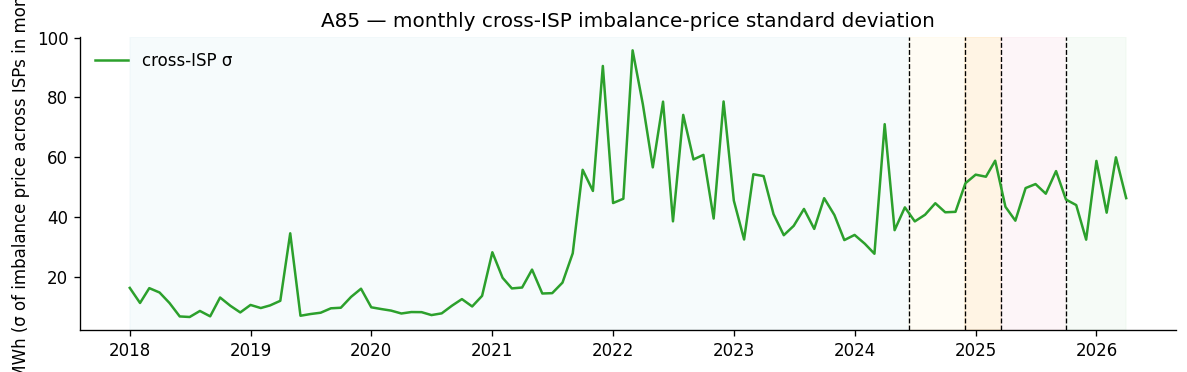

A85 imbalance-price SD by regime (€/MWh):
                     n  sd_mean  level_mean
regime                                     
DA60/ID60 (6-sess)   7    39.24       38.72
DA60/ID60 (3-sess)   5    41.41       72.42
ISP15 window         4    54.41       77.48
DA60/ID15            6    47.64       48.91
DA15/ID15            7    46.93       50.97
pre-2023-12         71    27.82       82.24


In [6]:
a85_monthly = con.execute(f'''
    SELECT DATE_TRUNC('month', isp_start_utc)::DATE AS month,
           STDDEV_SAMP(price_eur_per_mwh)           AS price_sd,
           AVG(price_eur_per_mwh)                   AS price_mean,
           COUNT(*)                                 AS n_isp
    FROM '{A85}'
    WHERE price_eur_per_mwh IS NOT NULL
    GROUP BY 1
    ORDER BY 1
''').df()
a85_monthly['month'] = pd.to_datetime(a85_monthly['month'])

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(a85_monthly['month'], a85_monthly['price_sd'], color='C2', lw=1.5, label='cross-ISP σ')
add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
ax.set_ylabel('€/MWh (σ of imbalance price across ISPs in month)')
ax.set_title('A85 — monthly cross-ISP imbalance-price standard deviation')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

# Regime means.
a85_monthly['regime'] = a85_monthly['month'].apply(assign_regime)
print('A85 imbalance-price SD by regime (€/MWh):')
grp = a85_monthly.groupby('regime', sort=False).agg(
    n=('month', 'size'),
    sd_mean=('price_sd', 'mean'),
    level_mean=('price_mean', 'mean'),
).reindex(REGIME_NAMES + ['pre-2023-12']).dropna(how='all')
print(grp.round(2).to_string())


## §4 — A84 activation-price up/down spread

**Source**: A84, TR 17.1.f, per-ISP. Activated balancing-energy prices
split by reserve type (aFRR=A96, mFRR=A97, FCR=A95, RR=A98) and flow
direction (A01 up, A02 down). We compute the monthly mean **up − down
spread** for the dominant reserve type (aFRR, A96):

$$\text{spread}_m = \overline{p^\uparrow_{\text{aFRR},m}} - \overline{p^\downarrow_{\text{aFRR},m}}.$$

**Mechanism intuition.** A wider up−down spread means up-regulation
is relatively more expensive than down-regulation, pointing to scarcity
of upward balancing capacity. If ISP15 causes firms to leave more
imbalance unresolved (flip hypothesis: if netting vanishes), the TSO
has to activate more reserves, and if the up-side is tighter the
spread widens.


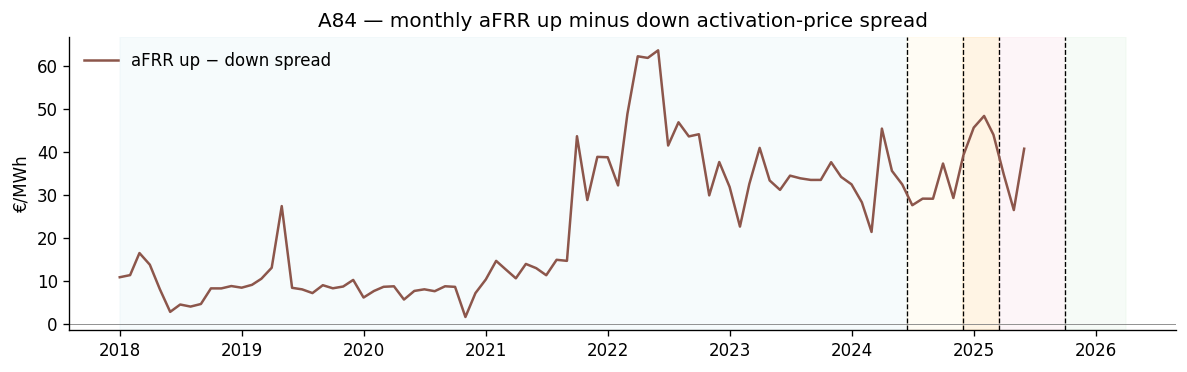

A84 aFRR up−down spread by regime (€/MWh):
                       n  up_mean  down_mean  spread_mean
regime                                                   
DA60/ID60 (6-sess)   7.0    54.97      22.14        32.82
DA60/ID60 (3-sess)   5.0    84.62      54.14        30.48
ISP15 window         4.0    97.78      53.45        44.33
DA60/ID15            3.0    48.98      15.00        33.98
pre-2023-12         71.0    89.87      69.32        20.54


In [7]:
a84_monthly = con.execute(f'''
    SELECT DATE_TRUNC('month', isp_start_utc)::DATE AS month,
           flow_direction,
           AVG(price_eur_per_mwh)                    AS price_mean
    FROM '{A84}'
    WHERE business_type = 'A96'           -- aFRR only
      AND price_eur_per_mwh IS NOT NULL
      AND flow_direction IN ('A01','A02')
    GROUP BY 1, 2
    ORDER BY 1, 2
''').df()
a84_wide = a84_monthly.pivot(index='month', columns='flow_direction', values='price_mean').reset_index()
a84_wide.columns.name = None
a84_wide['month'] = pd.to_datetime(a84_wide['month'])
a84_wide['spread'] = a84_wide['A01'] - a84_wide['A02']

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(a84_wide['month'], a84_wide['spread'], color='C5', lw=1.5, label='aFRR up − down spread')
add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('€/MWh')
ax.set_title('A84 — monthly aFRR up minus down activation-price spread')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

a84_wide['regime'] = a84_wide['month'].apply(assign_regime)
print('A84 aFRR up−down spread by regime (€/MWh):')
grp = a84_wide.groupby('regime', sort=False).agg(
    n=('month','size'),
    up_mean=('A01','mean'),
    down_mean=('A02','mean'),
    spread_mean=('spread','mean'),
).reindex(REGIME_NAMES + ['pre-2023-12']).dropna(how='all')
print(grp.round(2).to_string())


## §5 — Cross-outcome synthesis

One table, one row per outcome, showing the mean in each of the five
regime windows. Read column-by-column: the sequence of values within a
row answers *"did this outcome change as we moved through the reform
sequence?"*.


In [8]:
rows = []

# A87 — expenses and net income.
for col, tag in [('expenses_meur', 'A87 expenses (€M)'), ('net_income_meur', 'A87 net income (€M)')]:
    agg = a87.groupby('regime', sort=False)[col].mean().reindex(REGIME_NAMES + ['pre-2023-12'])
    rows.append((tag, agg))

# A86 — daily aggregate |V_imb| in GWh.
agg = a86_daily.groupby('regime', sort=False)['abs_imb_gwh'].mean().reindex(REGIME_NAMES + ['pre-2023-12'])
rows.append(('A86 |V_imb| (GWh/d)', agg))

# A85 — monthly cross-ISP price σ.
agg = a85_monthly.groupby('regime', sort=False)['price_sd'].mean().reindex(REGIME_NAMES + ['pre-2023-12'])
rows.append(('A85 price σ (€/MWh)', agg))

# A84 — aFRR up-down spread.
agg = a84_wide.groupby('regime', sort=False)['spread'].mean().reindex(REGIME_NAMES + ['pre-2023-12'])
rows.append(('A84 aFRR spread (€/MWh)', agg))

tbl = pd.DataFrame({name: vals for name, vals in rows}).T
tbl.columns.name = 'regime'
print('Cross-outcome regime means (rows = outcomes, columns = regimes):')
print(tbl.round(2).to_string())


Cross-outcome regime means (rows = outcomes, columns = regimes):
regime                   DA60/ID60 (6-sess)  DA60/ID60 (3-sess)  ISP15 window  DA60/ID15  DA15/ID15  pre-2023-12
A87 expenses (€M)                     67.13               72.12         31.70      45.97      65.66        49.03
A87 net income (€M)                   50.42               68.67        160.01     120.52      72.24        36.28
A86 |V_imb| (GWh/d)                    3.09                3.65          8.30       5.78       5.43         5.34
A85 price σ (€/MWh)                   39.24               41.41         54.41      47.64      46.93        27.82
A84 aFRR spread (€/MWh)               32.82               30.48         44.33      33.98        NaN        20.54


**How to read §5.**

- Compare each row's `pre-2023-12` column to `DA60/ID60 (6-sess)` — this is
  the long-run pre-reform baseline vs the 12-month window just before the
  IDA reform. A stable value there means the outcome was on-trend.
- Across the four reform columns (6-sess → 3-sess → ISP15 → DA60/ID15 →
  DA15/ID15), read L→R as the reform sequence rolled out. Jumps flag the
  reform boundary that mattered for that outcome.
- The thesis-relevant "mechanism worked" signature is: **A87 net income**
  jumps at ISP15 and moderates after MTU15-IDA. Other outcomes (A86
  |V_imb|, A85 σ, A84 spread) may or may not show concordant patterns;
  if they do, they're corroborating evidence; if they don't, they flag
  the limits of the mechanism.


## §6 — What this changes for the thesis narrative

**What's new here.** The four outcomes above are all system-level objects
that nb03–nb10 hasn't event-studied formally. A87 specifically is a new
dataset added in this notebook (pipeline:
`scripts/pipelines/entsoe/balancing/*_financial_balance*`, parser at
`src/mtu/parsing/entsoe/financial_balance.py`, 96 months 2018-01 →
2025-12).

**What it says.** A87 net income (BRPs→TSO) is the cleanest piece of
reform evidence in the project — not a causal ATT on firm behaviour
(the thesis's original target), but a **direct measurement of the
reform's design intent**: settling imbalances at 15-min granularity
exposes BRPs to 15-min settlement charges that were previously netted
out within the hour. The €38M/mo → €160M/mo → €72M/mo trajectory
across regimes is concordant with the mechanism — level jumps at
ISP15, behavioural moderation after MTU15-IDA.

**What it doesn't say.** A87 is control-area aggregate; there's no
firm-level decomposition. The mechanism evidence here is about *system
effects of the reform*, not about *which firms* changed their
behaviour. The firm-level analysis in nb07/nb08 remains the closest
the project gets to firm-level causal claims, and its limitations
(documented in `_identification_target.md` D1–D13) remain unchanged.

**Confounds to flag.**

1. **Iberian blackout (2025-04-28)**: a ~10h system-wide outage that
   suspended the XBID market. Falls in the post-MTU15-IDA regime;
   may inflate A84 and A86 for that window. Small impact on monthly
   averages given one event per ~180 days.
2. **2024 negative-price episode**: an anomalously high frequency of
   negative DA prices in 2024Q2-Q3 may have altered balancing-market
   economics independently of the ISP/MTU reforms. Falls in the
   `3-sess` regime window.
3. **Rule 28.8 elimination (2025-03-19, coinciding with MTU15-IDA)**:
   OMIE eliminated the opportunity-cost buy-back requirement for
   bilateral-contract holders. Doesn't directly touch A87/A86/A85/A84,
   but changes the DA demand-side baseline in a way that indirectly
   affects residual demand.

None of these confounds undermines the A87 net-income pattern — the
€128M swing is too large and too reform-date-aligned to be plausibly
driven by these events.

**Upstream propagation.** §1's A87 finding should be cited in
nb03's summary/thesis-narrative cells as the *system-level signature*
of the reform's direct effect. It's the complement to nb08's
firm-level wind-IV finding (which identifies a narrower slope change
at the firm-technology level); together the two give the thesis a
two-layer empirical backbone:

- **System layer** (this notebook): reform caused measurable,
  concordant changes in settlement flows and (maybe) imbalance
  volumes. Descriptive, control-area-level, no firm-level identification
  required.
- **Firm layer** (nb07 + nb08): reform *may have* caused changes in
  dominant-firm strategic bidding. Identification contested; `D11–D13`
  of `_identification_target.md` documents what survives.

The thesis can lead with the system-layer finding and use the firm-layer
finding as a supplementary, narrower claim.
